# Генерация датасета кадров LunarLander

Этот ноутбук создаёт синтетические RGB-кадры LunarLander с известными метками позы аппарата. Сгенерированный датасет хранится в `../../data`: каждому `.npy` изображению соответствует строка в `labels.csv`.

## Настройка рендера

`LunarLanderPoseGenerator` оборачивает рендер LunarLander из Gymnasium и вручную размещает аппарат в выбранных координатах пространства наблюдений. При синхронизации ног используется геометрия joint-anchor'ов Gymnasium: ноги остаются ниже корпуса и слегка отклонены наружу. Так можно получать supervised-метки для CV без запуска полных RL-эпизодов.

In [26]:
import math
from pathlib import Path

import gymnasium as gym
import numpy as np

from gymnasium.envs.box2d.lunar_lander import (
    VIEWPORT_W,
    VIEWPORT_H,
    SCALE,
    LEG_AWAY,
    LEG_DOWN,
)

class LunarLanderPoseGenerator:
    def __init__(self, render_mode="rgb_array"):
        self.env = gym.make(
            "LunarLander-v3",
            render_mode=render_mode,
            enable_wind=False,
            continuous=False,
        )
        self.base = self.env.unwrapped

    def close(self):
        self.env.close()

    @staticmethod
    def _set_body_pose(body, x, y, angle, vx=0.0, vy=0.0, omega=0.0):
        body.position = (x, y)
        body.angle = angle

        body.linearVelocity = (vx, vy)
        body.angularVelocity = omega
        body.awake = True

    def _obs_to_world_xy(self, x_obs, y_obs):
        W = VIEWPORT_W / SCALE
        H = VIEWPORT_H / SCALE

        x_world = x_obs * (W / 2.0) + (W / 2.0)
        y_world = y_obs * (H / 2.0) + (self.base.helipad_y + LEG_DOWN / SCALE)
        return x_world, y_world

    @staticmethod
    def _rotate_local(dx, dy, angle):
        cos_a = math.cos(angle)
        sin_a = math.sin(angle)
        return cos_a * dx - sin_a * dy, sin_a * dx + cos_a * dy

    def _sync_legs(self, lander_x, lander_y, lander_theta):
        for leg, i in zip(self.base.legs, [-1, +1]):
            leg_angle = lander_theta - i * 0.4
            anchor_x = i * (LEG_AWAY / SCALE)
            anchor_y = LEG_DOWN / SCALE

            dx, dy = self._rotate_local(anchor_x, anchor_y, leg_angle)
            leg_x = lander_x - 0.95 * dx
            leg_y = lander_y - dy

            self._set_body_pose(leg, leg_x, leg_y, leg_angle, 0.0, 0.0, 0.0)
            leg.ground_contact = False

    def reset_scene(self, seed=None):
        obs, info = self.env.reset(seed=seed)
        return obs, info

    def set_pose_from_obs(self, x_obs, y_obs, theta, vx=0.0, vy=0.0, omega=0.0):
        lander_x, lander_y = self._obs_to_world_xy(x_obs, y_obs)

        self._set_body_pose(
            self.base.lander,
            lander_x,
            lander_y,
            theta,
            vx=vx,
            vy=vy,
            omega=omega,
        )
        self._sync_legs(lander_x, lander_y, theta)

        self.base.game_over = False
        self.base.prev_shaping = None

    def render_frame(self):
        return self.base.render()

## Быстрая проверка одного кадра

Перед генерацией полного датасета отрендерим одну контролируемую позу. Это быстрая визуальная проверка того, что преобразование координат и ориентация аппарата работают ожидаемо.

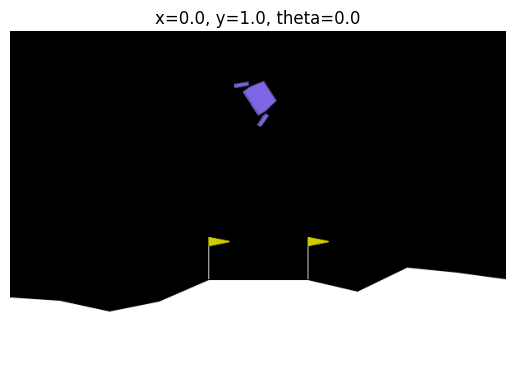

In [29]:
import matplotlib.pyplot as plt

gen = LunarLanderPoseGenerator()

gen.reset_scene(seed=27)
gen.set_pose_from_obs(x_obs=0, y_obs=1, theta=-1)

frame = gen.render_frame()

plt.imshow(frame)
plt.axis("off")
plt.title("x=0.0, y=1.0, theta=0.0")
plt.show()

gen.close()

## Сэмплирование и запись датасета

Генератор датасета сэмплирует `x`, `y` и `theta` из усечённых нормальных распределений, рендерит каждую позу, сохраняет изображение в формате `.npy` и записывает метки в `labels.csv`.

In [ ]:
from scipy.stats import truncnorm

def truncated_normal(mean, std, low, high, size=None, rng=940):
    a = (low - mean) / std
    b = (high - mean) / std

    return truncnorm.rvs(a, b, loc=mean, scale=std, size=size, random_state=rng)

def collect_synthetic_dataset(
    save_dir: str,
    n_scenes: int = 5000,
    samples_per_scene: int = 3,
    seed: int = 51,
    x_range=(-0.95, 0.95),
    y_range=(0.10, 1.40),
    theta_range=(-math.pi, math.pi),
):
    rng = np.random.default_rng(seed)
    save_path = Path(save_dir)
    img_dir = save_path / "images"
    img_dir.mkdir(parents=True, exist_ok=True)

    gen = LunarLanderPoseGenerator()
    rows = []
    idx = 0

    for scene_id in range(n_scenes):
        gen.reset_scene(seed=seed + scene_id)

        for _ in range(samples_per_scene):
            x_obs = truncated_normal(mean=np.mean(x_range), std=np.std(x_range) / 1.5, low=x_range[0], high=x_range[1])
            y_obs = truncated_normal(mean=np.mean(y_range), std=np.std(y_range) / 1.5, low=y_range[0], high=y_range[1])
            theta = truncated_normal(mean=np.mean(theta_range), std=np.std(theta_range) / 2, low=theta_range[0], high=theta_range[1])

            gen.set_pose_from_obs(x_obs=x_obs, y_obs=y_obs, theta=theta)
            frame = gen.render_frame()

            image_name = f"frame_{idx:07d}.npy"
            np.save(img_dir / image_name, frame)

            rows.append((image_name, x_obs, y_obs, theta, scene_id))
            idx += 1

    gen.close()

    with open(save_path / "labels.csv", "w", encoding="utf-8") as f:
        f.write("image_name,x,y,theta,scene_id\n")
        for row in rows:
            f.write(",".join(map(str, row)) + "\n")

    print(f"Сохранено {len(rows)} сэмплов в {save_path}")

## Генерация датасета

Запускайте эту ячейку, когда нужно пересобрать активный CV-датасет `x_y_theta`. Она запишет кадры в `../../data/images` и пересоздаст `labels.csv`.

In [ ]:
collect_synthetic_dataset("../../data")

## Проверка сохранённого кадра

Загрузим одно сохранённое изображение с диска, чтобы убедиться, что файлы читаются через NumPy и корректно отображаются в Matplotlib.

(400, 600, 3) uint8


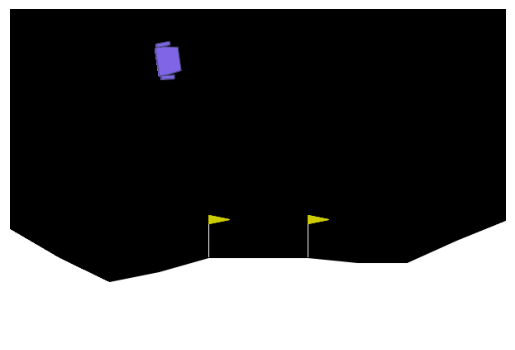

In [8]:
import numpy as np
import matplotlib.pyplot as plt

frame = np.load("../../data/images/frame_0000001.npy")

print(frame.shape, frame.dtype)

plt.imshow(frame)
plt.axis("off")
plt.show()

## Дополнительные превью поз

Эти небольшие превью полезны при настройке диапазонов поз и отладке того, как координаты пространства наблюдений отображаются в отрендеренные кадры. Во второй ячейке выставляйте x_obs = -MAEx, y_obs = 0.5 + MAEy, theta = MAEtheta для визуального определения диапазона чувствительности CV модели.

In [ ]:
import matplotlib.pyplot as plt

gen = LunarLanderPoseGenerator()

gen.reset_scene(seed=27)
gen.set_pose_from_obs(x_obs=0, y_obs=0.5, theta=0)

frame = gen.render_frame()

plt.imshow(frame)
plt.axis("off")
plt.show()

gen.close()

In [ ]:
import matplotlib.pyplot as plt

gen = LunarLanderPoseGenerator()

gen.reset_scene(seed=27)
gen.set_pose_from_obs(x_obs=-0.053, y_obs=0.52, theta=0.1)

frame = gen.render_frame()

plt.imshow(frame)
plt.axis("off")
plt.show()

gen.close()